In [76]:
from scipy.stats import linregress
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.optimize import minimize
from scipy.sparse.csgraph import minimum_spanning_tree
from scipy.linalg import eigh
import scipy.cluster.hierarchy as sch
from sklearn.cluster import KMeans
from sklearn.covariance import GraphicalLassoCV
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

try:
    from skopt import gp_minimize
    from skopt.space import Integer, Real
    print("Bayesian Optimization libraries (skopt) ready.")
except ImportError:
    print("Installing missing dependencies: scikit-optimize...")
    import subprocess
    import sys
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-optimize"])
        from skopt import gp_minimize
        from skopt.space import Integer, Real
        print("scikit-optimize installed and imported.")
    except:
        print("Could not install skopt. Bayesian strategies will fall back to static parameters.")

print("Libraries imported successfully!")

# --- Helper Functions for Hybrid MIS-NW ---

def apply_rmt_filter(returns_data):
    if isinstance(returns_data, pd.DataFrame):
        corr = returns_data.corr().values
        n_obs = len(returns_data)
    else:
        corr = returns_data
        n_obs = 120 # Default or estimate
        
    n_assets = corr.shape[1]
    if n_assets == 1: return np.array([[1.0]])
    Q = n_obs / n_assets
    eigenvalues, eigenvectors = np.linalg.eigh(corr)
    sigma2 = 1 - np.mean(eigenvalues) 
    lambda_plus = sigma2 * (1 + (1/Q) + 2*np.sqrt(1/Q))
    eigenvalues_filtered = np.where(eigenvalues > lambda_plus, eigenvalues, np.mean(eigenvalues[eigenvalues <= lambda_plus]))
    corr_denoised = eigenvectors @ np.diag(eigenvalues_filtered) @ eigenvectors.T
    d = np.diag(1 / np.sqrt(np.diag(corr_denoised)))
    corr_denoised = d @ corr_denoised @ d
    return corr_denoised

def build_mst(corr_matrix):
    distance = np.sqrt(2 * (1 - np.clip(corr_matrix, -1, 1)))
    mst = minimum_spanning_tree(distance).toarray()
    mst = mst + mst.T
    return mst

def compute_eigenvector_centrality(dist_matrix):
    adj = 1.0 / (1.0 + dist_matrix)
    np.fill_diagonal(adj, 0)
    eigenvalues, eigenvectors = eigh(adj)
    centrality = np.abs(eigenvectors[:, -1])
    return centrality / np.sum(centrality)

def get_assets_graph_diversify_rmt(returns, correlation_threshold=0.5):
    corr_denoised = apply_rmt_filter(returns)
    adj = (np.abs(corr_denoised) > correlation_threshold).astype(int)
    np.fill_diagonal(adj, 0)
    G = nx.from_numpy_array(adj)
    coloring = nx.greedy_color(G, strategy='largest_first')
    independent_set_indices = [node for node, color in coloring.items() if color == 0]
    return independent_set_indices

Bayesian Optimization libraries (skopt) ready.
Libraries imported successfully!


In [77]:
excel_file = 'crypto_data_real.xlsx'
df_returns = pd.read_excel(excel_file, sheet_name='Returns', index_col=0)
df_prices  = pd.read_excel(excel_file, sheet_name='Prices',  index_col=0)

crypto_names = df_returns.columns.tolist()
n_assets     = len(crypto_names)

print(f"Data loaded: {df_returns.shape[0]} days, {n_assets} assets")
print(f"Period: {df_returns.index[0]} to {df_returns.index[-1]}")

Data loaded: 763 days, 10 assets
Period: 2017-09-15 00:00:00 to 2019-10-17 00:00:00


In [78]:
summary_stats = pd.DataFrame({
    'Mean':     df_returns.mean(),
    'Std':      df_returns.std(),
    'Kurtosis': df_returns.kurt(),
    'Skewness': df_returns.skew()
})

print("TABLE 1 | Summary statistics.")
print(summary_stats.round(4))

TABLE 1 | Summary statistics.
        Mean     Std  Kurtosis  Skewness
BTC   0.0012  0.0434    3.0822    0.0523
ETH  -0.0008  0.0507    2.8209   -0.2916
XRP   0.0004  0.0654   18.9009    2.0588
USDT -0.0000  0.0057   21.7209    0.7437
BCH  -0.0014  0.0724    7.5671    0.6231
LTC   0.0004  0.0585    6.6357    1.0988
BNB   0.0029  0.0621   10.2612    1.0694
EOS   0.0012  0.0709    4.7582    0.5781
XLM   0.0006  0.0657    7.0332    0.9799
TRX   0.0025  0.0879   22.1856    2.6905


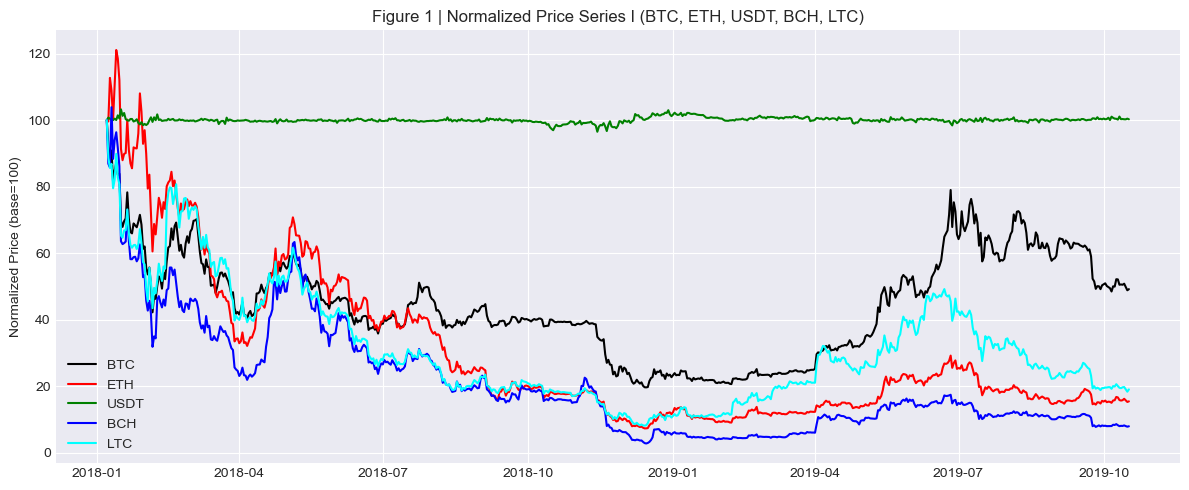

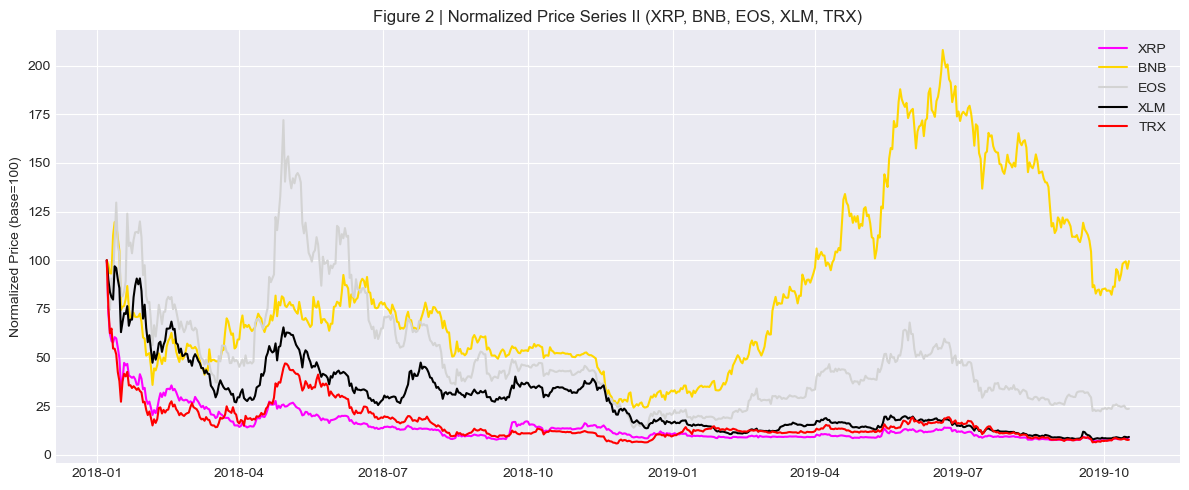

In [79]:
assets_1 = ['BTC', 'ETH', 'USDT', 'BCH', 'LTC']
df_norm_1 = (df_prices.loc['2018-01-07':, assets_1] /
             df_prices.loc['2018-01-07', assets_1]) * 100

colors_1 = ['black', 'red', 'green', 'blue', 'cyan']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_1.columns):
    plt.plot(df_norm_1.index, df_norm_1[col],
             label=col, color=colors_1[i])
plt.title('Figure 1 | Normalized Price Series I (BTC, ETH, USDT, BCH, LTC)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

assets_2 = ['XRP', 'BNB', 'EOS', 'XLM', 'TRX']
df_norm_2 = (df_prices.loc['2018-01-07':, assets_2] /
             df_prices.loc['2018-01-07', assets_2]) * 100

colors_2 = ['magenta', 'gold', 'lightgrey', 'black', 'red']

plt.figure(figsize=(12, 5))
for i, col in enumerate(df_norm_2.columns):
    plt.plot(df_norm_2.index, df_norm_2[col],
             label=col, color=colors_2[i])
plt.title('Figure 2 | Normalized Price Series II (XRP, BNB, EOS, XLM, TRX)')
plt.ylabel('Normalized Price (base=100)')
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
class PortfolioStrategy:
    def __init__(self, name, window_size=120):
        self.name            = name
        self.window_size     = window_size
        self.weights_history = []
        self.returns_history = []
        self.param_history   = []
        
    def get_weights(self, returns_data):
        raise NotImplementedError
        
    def get_params(self):
        return {}

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        S  = filtered_data.cov().fillna(0).values
        S  += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class GlassoMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(filtered_data.values)
            S = glasso.covariance_
        except Exception:
            S = filtered_data.cov().fillna(0).values
        S += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name="Network Markowitz", gamma=0, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.W = window_size

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights
    
    def get_params(self):
        return {'W': self.W, 'gamma': self.gamma}

class HybridMISNetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name="Hybrid MIS-NW", gamma=0, window_size=120, correlation_threshold=0.5, t=None):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.W = window_size
        self.T = t if t is not None else correlation_threshold

    def get_weights(self, returns_data):
        # 1. Asset Selection via MIS (RMT)
        mis_res = get_assets_graph_diversify_rmt(returns_data, self.T)
        n_assets = returns_data.shape[1]
        
        if len(mis_res) == 0:
             return np.ones(n_assets) / n_assets
             
        # Map back to integer indices if string names were returned
        if isinstance(mis_res[0], (str, np.str_)):
            mis_indices = [returns_data.columns.get_loc(name) for name in mis_res]
        else:
            mis_indices = mis_res
        
        # Subset data
        subset_data = returns_data.loc[:, mis_indices]
        mu = subset_data.mean().values
        sig = subset_data.std().values
        Cf = apply_rmt_filter(subset_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu), method='SLSQP', bounds=[(0, 1)] * len(mu), constraints=constraints)
        final_weights = np.zeros(n_assets)
        if res.success:
            for i, idx_pos in enumerate(mis_indices): final_weights[idx_pos] = res.x[i]
        else:
            for idx_pos in mis_indices: final_weights[idx_pos] = 1.0 / len(mis_indices)
        return final_weights
        
    def get_params(self):
        return {'W': self.W, 'gamma': self.gamma, 'T': self.T}


class NetworkCVaR(PortfolioStrategy):
    def __init__(self, name="NW + CVaR", alpha=0.95, gamma=0.5, window_size=120):
        super().__init__(name, window_size)
        self.alpha = alpha
        self.gamma = gamma
        self.W = window_size
        
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        
        filtered_data = returns_data.loc[:, valid_assets]
        R = filtered_data.values
        T, N = R.shape
        
        # NW Components: Filter, Structure, Centrality
        Cf = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        
        # CVaR Objective with Centrality Penalty
        def objective(x):
            w = x[:N]
            zeta = x[N]
            portfolio_losses = - (R @ w)
            excess_losses = np.maximum(0, portfolio_losses - zeta)
            cvar = zeta + (1.0 / (T * (1.0 - self.alpha))) * np.sum(excess_losses)
            return cvar + self.gamma * np.sum(cent * w)

        # Initial guess: EW and VaR at alpha
        x0 = np.zeros(N + 1)
        x0[:N] = 1.0 / N
        x0[N] = np.percentile(-(R @ x0[:N]), self.alpha * 100)
        
        bounds = [(0, 1)] * N + [(None, None)]
        constraints = [{'type': 'eq', 'fun': lambda x: np.sum(x[:N]) - 1.0}]
        
        res = minimize(objective, x0, method='SLSQP', bounds=bounds, constraints=constraints)
        
        weights = np.zeros(n_assets)
        if res.success:
            weights[valid_assets] = res.x[:N]
        else:
            weights[valid_assets] = 1.0 / N
        return weights
    
    def get_params(self):
        return {'W': self.W, 'gamma': self.gamma, 'alpha': self.alpha}

class NetworkMaxReturn(PortfolioStrategy):
    def __init__(self, name="NW + Max Return", gamma=0.5, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.W = window_size
        
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        
        # NW Components: Filter, Structure, Centrality
        Cf = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        
        # Objective: Maximize (Return - gamma * Centrality)
        # minimize: - (w @ mu) + gamma * (w @ cent)
        objective = lambda w: - np.sum(w * mu) + self.gamma * np.sum(cent * w)
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
        ]
        bounds = [(0, 1)] * len(mu)
        
        res = minimize(objective, np.ones(len(mu)) / len(mu), method='SLSQP', bounds=bounds, constraints=constraints)
        
        weights = np.zeros(n_assets)
        if res.success:
            weights[valid_assets] = res.x
        else:
            weights[valid_assets] = 1.0 / len(mu)
        return weights
    
    def get_params(self):
        return {'W': self.W, 'gamma': self.gamma}
class HierarchicalRiskParity(PortfolioStrategy):
    def get_weights(self, returns_data):
        cov = returns_data.cov().fillna(0).values
        ivp = 1. / (np.diag(cov) + 1e-9)
        return ivp / np.sum(ivp)

class KMeansPortfolioStrategy(PortfolioStrategy):
    def __init__(self, name="K-Means Portfolio", n_clusters=4, window_size=120):
        super().__init__(name, window_size)
        self.n_clusters = n_clusters
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        corr = returns_data.corr().fillna(0).values
        kmeans = KMeans(n_clusters=min(self.n_clusters, n_assets), random_state=42)
        kmeans.fit(corr)
        clusters = kmeans.labels_
        cluster_weights = np.zeros(n_assets)
        for i in range(max(clusters) + 1):
            idx = np.where(clusters == i)[0]
            if len(idx) > 0: cluster_weights[idx] = 1.0 / (len(idx) * (max(clusters) + 1))
        return cluster_weights




class AdaptiveNetworkMarkowitz(NetworkMarkowitz):
    def __init__(self, name="Adaptive NW", gamma=1, window_size=30, slope_threshold=0, p_threshold=0.05):
        super().__init__(name, gamma, window_size)
        self.base_gamma = gamma
        self.W = window_size
        self.slope_threshold = slope_threshold
        self.p_threshold = p_threshold
        self.gamma_history = []

    def get_weights(self, returns_data):
        mean_rets = returns_data.mean(axis=1)
        cum_rets = (1 + mean_rets).cumprod()
        x = np.arange(len(cum_rets))
        slope, intercept, r_value, p_value, std_err = linregress(x, cum_rets.values)
        
        # Use slope_threshold instead of hardcoded 0
        if slope > self.slope_threshold and p_value < self.p_threshold:
            current_gamma = 0
        else:
            current_gamma = self.base_gamma
            
        self.gamma = current_gamma
        current_date = returns_data.index[-1]
        self.gamma_history.append({'date': current_date, 'gamma': current_gamma})
        
        return super().get_weights(returns_data)
    
    def get_params(self):
        return {'W': self.W, 'gamma': self.base_gamma, 'slope_threshold': self.slope_threshold}


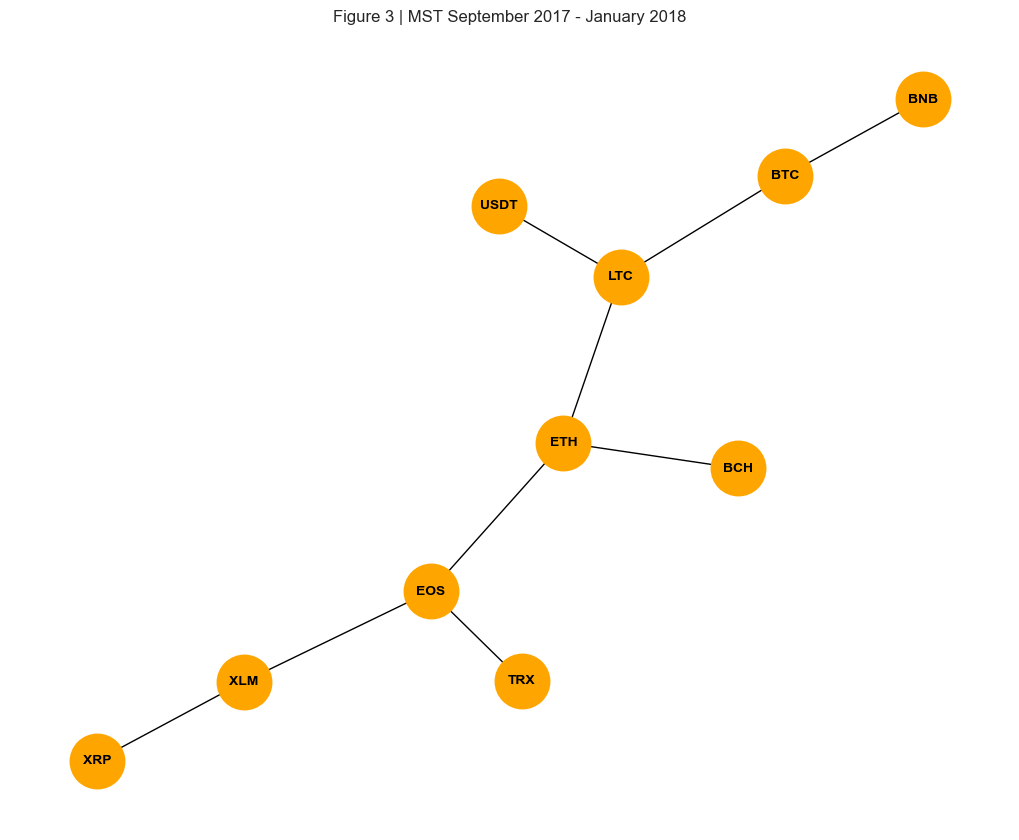

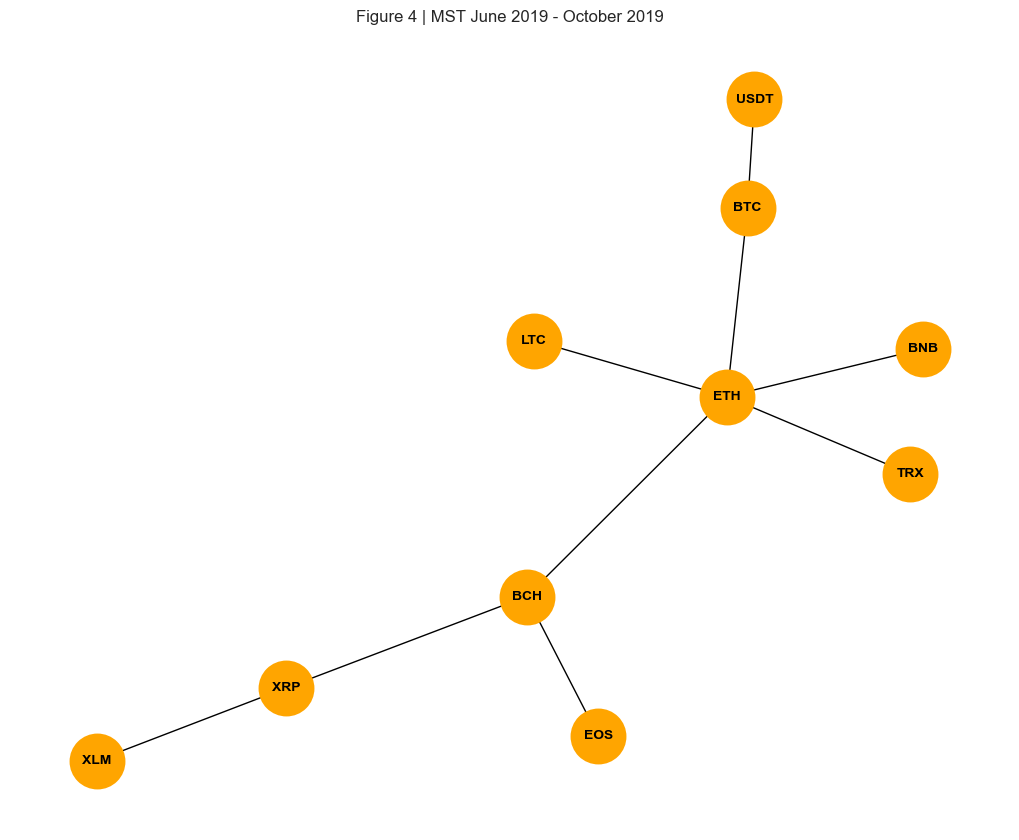

In [81]:
df_bubble   = df_returns.loc['2017-09-14':'2018-01-31']
corr_bubble = df_bubble.corr()
dist_bubble = np.sqrt(2 * (1 - corr_bubble))

G          = nx.from_pandas_adjacency(dist_bubble)
mst_bubble = nx.minimum_spanning_tree(G, weight='weight')

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(mst_bubble, seed=42)
nx.draw(mst_bubble, pos, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 3 | MST September 2017 - January 2018', fontsize=12)
plt.show()

df_stable   = df_returns.loc['2019-06-01':'2019-10-17']
corr_stable = df_stable.corr()
dist_stable = np.sqrt(2 * (1 - corr_stable))

G2         = nx.from_pandas_adjacency(dist_stable)
mst_stable = nx.minimum_spanning_tree(G2, weight='weight')

plt.figure(figsize=(10, 8))
pos2 = nx.spring_layout(mst_stable, seed=42)
nx.draw(mst_stable, pos2, with_labels=True, node_color='orange',
        node_size=1500, edge_color='black', linewidths=1.5,
        font_size=10, font_weight='bold')
plt.title('Figure 4 | MST June 2019 - October 2019', fontsize=12)
plt.show()

In [82]:
def apply_rmt_filter(returns_data):
    """
    Menerapkan filter Random Matrix Theory (RMT) pada matriks korelasi aset.
    
    Fungsi ini bertujuan untuk memisahkan "sinyal" (informasi pasar yang sebenarnya) 
    dari "noise" (fluktuasi acak) dalam matriks korelasi imbal hasil (returns) aset. 
    Metode ini sangat berguna dalam optimasi portofolio untuk mencegah terjadinya over-fitting 
    terhadap noise historis, sehingga estimasi matriks korelasi yang dihasilkan menjadi 
    lebih stabil dan dapat diandalkan (robust).

    Alur Narasi Proses:
    1. Persiapan Data: Memastikan data berformat matriks numpy agar siap diolah.
    2. Korelasi Empiris: Membentuk matriks korelasi Pearson standar dari data imbal hasil.
    3. Dekomposisi Eigen: Memecah matriks korelasi menjadi nilai eigen dan vektor eigen untuk 
       melihat varians dari komponen utama.
    4. Thresholding Marchenko-Pastur: Menghitung ambang batas (lambda_plus) acak 
       berdasarkan teori matriks acak.
    5. Penyaringan (Filtering): Memilah mana nilai eigen yang "nyata" (sinyal) 
       dan mana yang "acak" (noise). Noise kemudian dihilangkan (di-nol-kan).
    6. Rekonstruksi: Membangun kembali matriks korelasi baru yang sudah dibersihkan dari noise.

    Parameters:
    -----------
    returns_data : pandas.DataFrame atau numpy.ndarray
        Data deret waktu imbal hasil (returns) dari berbagai aset. 
        Asumsi format: Baris (T observasi) x Kolom (N aset).

    Returns:
    --------
    C_filtered : numpy.ndarray
        Matriks korelasi baru (N x N) yang telah disaring dan dibersihkan dari noise.
    """
    
    if isinstance(returns_data, pd.DataFrame):
        data = returns_data.values
    else:
        data = returns_data
        
    T, N = data.shape
    if N == 1: return np.array([[1.0]])
    
    Q = T / N
    
    C = np.corrcoef(data.T)

    eigenvalues, eigenvectors = eigh(C)
    
    eigenvalues  = eigenvalues[::-1]
    eigenvectors = eigenvectors[:, ::-1]

    lambda_plus = 1 + (1/Q) + 2*np.sqrt(1/Q)
    
    significant_mask = eigenvalues > lambda_plus

    Lambda_filtered = np.diag(np.where(significant_mask, eigenvalues, 0))
    
    C_filtered = eigenvectors @ Lambda_filtered @ eigenvectors.T
    
    return C_filtered

def build_mst(correlation_matrix):
    """
    Menghitung matriks jarak (Distance Matrix) dari matriks korelasi sebagai
    tahap pra-pemrosesan untuk pembentukan Minimum Spanning Tree (MST).
    
    Transformasi ini menggunakan metrik jarak Mantegna (1999) yang secara
    umum didefinisikan sebagai d_ij = sqrt(2 * (1 - rho_ij)). Metrik ini
    mentransformasikan korelasi (Pearson) ke dalam ruang Euclidean.
    
    Matematika Transformasi:
    1. Jika rho =  1 (Korelasi Positif Sempurna), maka d = 0 (Jarak terdekat).
    2. Jika rho =  0 (Tidak Ada Korelasi),       maka d = sqrt(2) ≈ 1.41.
    3. Jika rho = -1 (Korelasi Negatif Sempurna), maka d = 2 (Jarak terjauh).
    
    Parameters:
    -----------
    correlation_matrix : numpy.ndarray
        Matriks korelasi antar aset berukuran (N x N). Matriks ini harus
        bersifat simetris dan memiliki nilai diagonal bernilai 1.0.
        
    Returns:
    --------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N) yang memenuhi sifat-sifat metrik:
        - Non-negatif: d_ij >= 0
        - Identitas: d_ii = 0
        - Simetris: d_ij = d_ji
        - Ketidaksamaan Segitiga: d_ij <= d_ik + d_kj
    """
    
    distance_matrix = np.sqrt(2 - 2 * correlation_matrix)
    
    np.fill_diagonal(distance_matrix, 0)
    
    return distance_matrix

def compute_eigenvector_centrality(distance_matrix):
    """
    Menghitung skor Eigenvector Centrality dari matriks jarak (Distance Matrix).
    
    Eigenvector centrality memberikan ukuran seberapa 'penting' suatu aset 
    di dalam jaringan. Berbeda dengan degree centrality (yang hanya menghitung 
    jumlah koneksi), eigenvector centrality mempertimbangkan kualitas koneksi; 
    suatu aset dianggap penting jika ia terhubung dengan aset-aset lain yang 
    juga memiliki kepentingan tinggi.
    
    Dalam studi portofolio (Network Markowitz), metrik ini digunakan untuk 
    mendeteksi aset sistemik atau aset yang berada di pusat kluster risiko.
    Parameters:
    -----------
    distance_matrix : numpy.ndarray
        Matriks jarak berukuran (N x N). Nilai kecil pada matriks ini 
        menunjukkan korelasi yang kuat antar aset.
    Returns:
    --------
    centrality : numpy.ndarray
        Vektor berukuran (N,) berisi skor centrality yang dinormalisasi.
        Nilai yang lebih tinggi menunjukkan aset yang lebih sentral di pasar.
    """
    
    adjacency = 1 / (distance_matrix + 1e-8)
    
    np.fill_diagonal(adjacency, 0)
    
    eigenvalues, eigenvectors = eigh(adjacency)
    
    principal_eigenvector = np.abs(eigenvectors[:, -1])
    
    centrality = principal_eigenvector / principal_eigenvector.sum()
    
    return centrality

def calculate_var(returns, confidence=0.95):
    """
    Menghitung Value at Risk (VaR) menggunakan metode Simulasi Historis.
    
    Value at Risk (VaR) adalah metrik risiko statistik yang mengestimasi 
    potensi kerugian maksimum dalam portofolio pada tingkat kepercayaan 
    tertentu dalam periode waktu tertentu.
    
    Contoh Interpretasi:
    Jika VaR(95%) bernilai -0.02, artinya kita memiliki keyakinan 95% bahwa 
    kerugian portofolio tidak akan melebihi 2% dalam satu hari kerja, 
    atau terdapat peluang 5% bahwa kerugian akan melampaul 2%.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (return) dari aset atau portofolio.
    confidence : float, default 0.95
        Tingkat kepercayaan (confidence level). 0.95 berarti kita fokus 
        pada 5% kemungkinan terburuk (significance level alpha = 0.05).

    Returns:
    --------
    var_value : float
        Nilai batas bawah (threshold) imbal hasil pada persentil yang ditentukan.
    """
    
    alpha = 1 - confidence
    
    var_value = np.percentile(returns, alpha * 100)
    
    return var_value

def calculate_rachev_ratio(returns, alpha=0.10):
    """
    Menghitung Rachev Ratio untuk mengukur efisiensi imbal hasil pada ekor distribusi.
    
    Rachev Ratio mengukur perbandingan antara potensi keuntungan ekstrem (reward) 
    terhadap potensi kerugian ekstrem (risk). Berbeda dengan Sharpe Ratio, 
    metrik ini sangat efektif untuk aset dengan distribusi non-normal (fat-tails) 
    dan asimetris (skewed), yang umum ditemukan di pasar cryptocurrency.

    Formula:
    Rachev Ratio = CVaR(alpha, upper) / CVaR(alpha, lower)

    Interpretasi:
    Nilai > 1 menunjukkan bahwa potensi keuntungan di ekor kanan distribusi 
    lebih besar dibandingkan potensi kerugian di ekor kiri pada tingkat kepercayaan 1-alpha.

    Parameters:
    -----------
    returns : numpy.ndarray | pandas.Series
        Data historis imbal hasil (returns) strategi.
    alpha : float, default 0.10
        Tingkat signifikansi (probability tail). Misal 0.10 berarti kita 
        menganalisis 10% kejadian paling ekstrem (terbaik vs terburuk).

    Returns:
    --------
    rachev_ratio : float
        Rasio antara CVaR Atas per CVaR Bawah.
    """
    
    threshold_upper = np.percentile(returns, (1 - alpha) * 100)
    threshold_lower = np.percentile(returns, alpha * 100)
    
    cvar_upper = returns[returns >= threshold_upper].mean()
    
    cvar_lower = abs(returns[returns <= threshold_lower].mean())
    
    if cvar_lower > 0:
        rachev_ratio = cvar_upper / cvar_lower
    else:
        rachev_ratio = 0
        
    return rachev_ratio

def calculate_max_drawdown(cumulative_returns):
    """
    Menghitung Maximum Drawdown (MDD) dari deret imbal hasil kumulatif.
    
    Maximum Drawdown mengukur penurunan persentase terbesar yang diamati dari 
    titik puncak (peak) ke titik terendah (trough) dalam suatu periode waktu, 
    sebelum titik puncak baru terbentuk. Ini mencerminkan risiko kerugian 
    ekstrem yang mungkin dialami investor.

    Interpretasi:
    - Jika MDD = -0.25, berarti strategi tersebut pernah mengalami penurunan 
      nilai sebesar 25% dari titik tertingginya.
    - Semakin mendekati 0, semakin baik ketahanan strategi dalam menjaga modal.

    Parameters:
    -----------
    cumulative_returns : numpy.ndarray | pandas.Series
        Deret imbal hasil kumulatif (kurva ekuitas). 
        Pastikan input adalah data kumulatif (misal: 1, 1.05, 1.02, 1.08).

    Returns:
    --------
    max_drawdown : float
        Nilai penurunan maksimum dalam bentuk desimal (selalu <= 0).
    """

    running_max = np.maximum.accumulate(cumulative_returns)
    
    drawdown = (cumulative_returns - running_max) / running_max
    
    max_drawdown = drawdown.min()

    return max_drawdown

def get_assets_graph_diversify(returns_window, corr_threshold=0.4):
    """
    Melakukan seleksi aset untuk diversifikasi menggunakan algoritma 
    Maximum Independent Set (MIS) berbasis teori jaringan.
    
    Konsep Dasar Jaringan:
    1. Node (Simpul): Mewakili aset kripto dalam semesta portofolio.
    2. Edge (Sisi): Menghubungkan dua aset jika korelasi absolutnya melampaui 
       batas 'corr_threshold'. Sisi ini melambangkan 'redundansi' informasi risiko.
    3. Independent Set: Kumpulan aset yang TIDAK saling terhubung satu sama lain.
       Artinya, tidak ada aset dalam set ini yang memiliki korelasi tinggi.
    
    Tujuan Utama:
    Menemukan jumlah aset terbanyak yang memiliki tingkat ketergantungan (korelasi) 
    paling rendah satu sama lain demi memaksimalkan efek diversifikasi.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Window data historis return aset (T bare x N kolom).
    corr_threshold : float, default 0.4
        Parameter theta (θ). Ambang batas di mana korelasi dianggap 'terlalu kuat'.
        Semakin rendah nilainya, semakin sedikit aset yang terpilih (diversifikasi sangat ketat).
    Returns:
    --------
    selected_assets : list
        Daftar nama aset terverifikasi yang membentuk Independent Set terbesar.
    """
    
    corr_mat = returns_window.corr()
    
    G = nx.Graph()
    
    assets = list(returns_window.mean()
                    .sort_values(ascending=False).index)
    
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for a2 in assets[i+1:]:
            if abs(corr_mat.loc[a1, a2]) > corr_threshold:
                G.add_edge(a1, a2)
    
    selected_assets = list(nx.approximation.maximum_independent_set(G))
    
    return selected_assets

def get_assets_graph_diversify_rmt(returns_window, corr_threshold=0.4):
    """
    Menyeleksi aset independen melalui jaringan graf yang telah difilter 
    menggunakan Random Matrix Theory (RMT).
    
    Keunggulan Metodologi RMT-Graph:
    1. Korelasi historis standar seringkali dipenuhi oleh 'noise' (gangguan) 
       akibat window data yang terbatas (fat-tails).
    2. RMT memisahkan eigenvalue korelasi menjadi dua bagian: 'noise' (yang 
       berada dalam bulk Marchenko-Pastur) dan 'signal' (eigenvalue yang keluar).
    3. Dengan menggunakan 'Filtered Correlation' (corr_f), sisi (edge) pada 
       graf hanya ditarik jika terdapat hubungan ekonomi yang benar-benar 
       signifikan (pure signal), bukan karena kebetulan statistik.
    Parameters:
    -----------
    returns_window : pandas.DataFrame
        Dataframe imbal hasil aset (N x T).
    corr_threshold : float, default 0.4
        Ambang batas (theta) untuk menentukan apakah signal korelasi 
        cukup kuat untuk membentuk koneksi antar aset.
    Returns:
    --------
    selected_assets_rmt : list
        Kumpulan aset independen (Maximum Independent Set) hasil filter RMT.
    """
    
    assets = returns_window.columns.tolist()
    
    corr_f = apply_rmt_filter(returns_window)
    
    G = nx.Graph()
    G.add_nodes_from(assets)
    
    for i, a1 in enumerate(assets):
        for j, a2 in enumerate(assets):
            if i < j:
                if abs(corr_f[i, j]) > corr_threshold:
                    G.add_edge(a1, a2)
    
    selected_assets_rmt = list(nx.approximation.maximum_independent_set(G))
    
    return selected_assets_rmt

print("Helper functions defined successfully!")

Helper functions defined successfully!


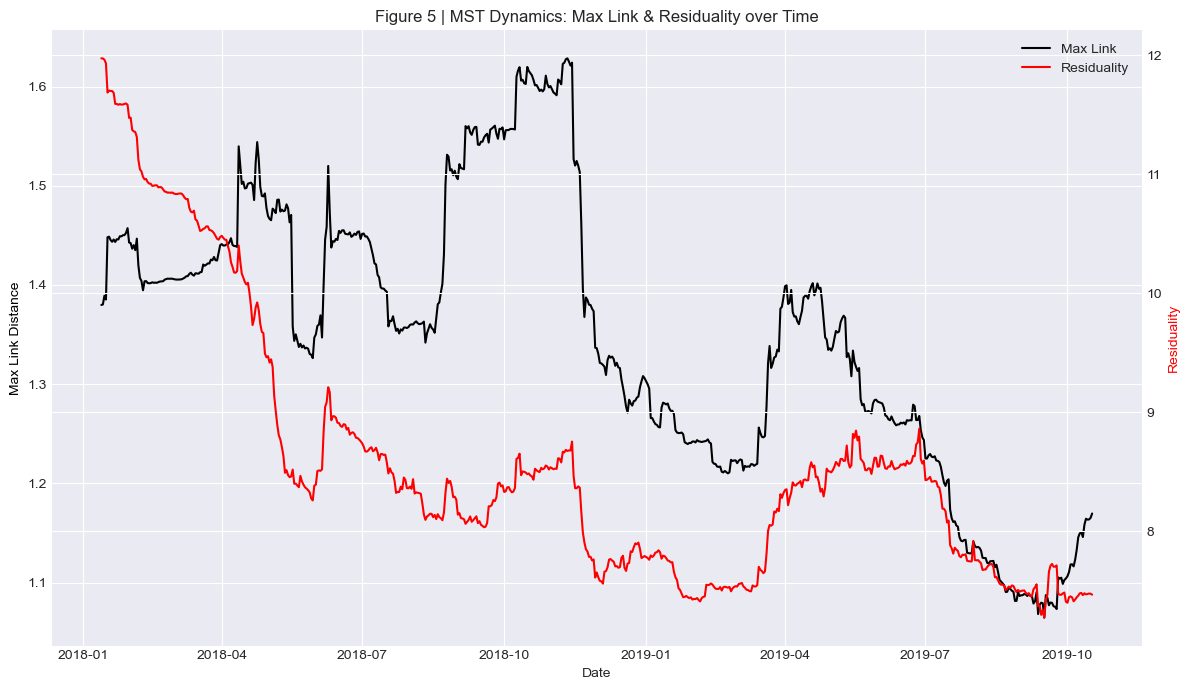

In [83]:
def calculate_rolling_mst_metrics(returns_df, window=120):
    """Hitung dinamika MST dengan rolling window."""
    dates          = returns_df.index[window:]
    max_links      = []
    residualities  = []
    for i in range(window, len(returns_df)):
        window_data = returns_df.iloc[i - window:i]
        corr_f      = apply_rmt_filter(window_data)
        mst_weights = build_mst(corr_f)
        max_links.append(np.max(mst_weights))
        residualities.append(
            np.sum(mst_weights) / (returns_df.shape[1] - 1)
        )
    return pd.DataFrame(
        {'Max Link': max_links, 'Residuality': residualities},
        index=dates
    )

mst_dyn = calculate_rolling_mst_metrics(df_returns)

fig, ax1 = plt.subplots(figsize=(12, 7))
ax1.plot(mst_dyn.index, mst_dyn['Max Link'],
         color='black', label='Max Link')
ax1.set_ylabel('Max Link Distance', color='black')
ax1.set_xlabel('Date')

ax2 = ax1.twinx()
ax2.plot(mst_dyn.index, mst_dyn['Residuality'],
         color='red', label='Residuality')
ax2.set_ylabel('Residuality', color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Figure 5 | MST Dynamics: Max Link & Residuality over Time')
plt.tight_layout()
plt.show()

In [84]:
class PortfolioStrategy:
    def __init__(self, name, window_size=120):
        self.name            = name
        self.window_size     = window_size
        self.weights_history = []
        self.returns_history = []
        self.param_history   = []
        
    def get_weights(self, returns_data):
        raise NotImplementedError
        
    def get_params(self):
        return {}

class EquallyWeighted(PortfolioStrategy):
    def get_weights(self, returns_data):
        n = returns_data.shape[1]
        return np.ones(n) / n

class ClassicalMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        S  = filtered_data.cov().fillna(0).values
        S  += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class GlassoMarkowitz(PortfolioStrategy):
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        try:
            glasso = GraphicalLassoCV()
            glasso.fit(filtered_data.values)
            S = glasso.covariance_
        except Exception:
            S = filtered_data.cov().fillna(0).values
        S += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ S @ w
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights

class NetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name="Network Markowitz", gamma=0, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.W = window_size

    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        filtered_data = returns_data.loc[:, valid_assets]
        mu   = filtered_data.mean().values
        sig  = filtered_data.std().values
        Cf   = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf   = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective   = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu),
                       method='SLSQP',
                       bounds=[(0, 1)] * len(mu),
                       constraints=constraints)
        weights = np.zeros(n_assets)
        weights[valid_assets] = res.x if res.success else (np.ones(len(mu)) / len(mu))
        return weights
    
    def get_params(self):
        return {'W': self.W, 'gamma': self.gamma}

class HybridMISNetworkMarkowitz(PortfolioStrategy):
    def __init__(self, name="Hybrid MIS-NW", gamma=0, window_size=120, correlation_threshold=0.5, t=None):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.W = window_size
        self.T = t if t is not None else correlation_threshold

    def get_weights(self, returns_data):
        mis_indices = get_assets_graph_diversify_rmt(returns_data, self.T)
        n_assets = returns_data.shape[1]
        if len(mis_indices) == 0: return np.ones(n_assets) / n_assets
        if len(mis_indices) == 1:
            final_weights = np.zeros(n_assets)
            final_weights[returns_data.columns.get_loc(mis_indices[0])] = 1.0
            return final_weights
        subset_data = returns_data.loc[:, mis_indices]
        mu = subset_data.mean().values
        sig = subset_data.std().values
        Cf = apply_rmt_filter(subset_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        Sf = np.outer(sig, sig) * Cf
        Sf += np.eye(len(mu)) * 1e-8
        objective = lambda w: w @ Sf @ w + self.gamma * np.sum(cent * w)
        constraints = [
            {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
            {'type': 'ineq', 'fun': lambda w: w @ mu - mu.mean()}
        ]
        res = minimize(objective, np.ones(len(mu)) / len(mu), method='SLSQP', bounds=[(0, 1)] * len(mu), constraints=constraints)
        final_weights = np.zeros(n_assets)
        if res.success:
            for asset, w_val in zip(mis_indices, res.x): final_weights[returns_data.columns.get_loc(asset)] = w_val
        else:
            for asset in mis_indices: final_weights[returns_data.columns.get_loc(asset)] = 1.0 / len(mis_indices)
        return final_weights
        
    def get_params(self):
        return {'W': self.W, 'gamma': self.gamma, 'T': self.T}


class NetworkMaxReturn(PortfolioStrategy):
    def __init__(self, name="NW + Max Return", gamma=0.5, window_size=120):
        super().__init__(name, window_size)
        self.gamma = gamma
        self.W = window_size
        
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        std = returns_data.std()
        valid_assets = std > 1e-12
        if not valid_assets.any(): return np.ones(n_assets) / n_assets
        
        filtered_data = returns_data.loc[:, valid_assets]
        mu = filtered_data.mean().values
        
        # NW Components: Filter, Structure, Centrality
        Cf = apply_rmt_filter(filtered_data)
        dist = build_mst(Cf)
        cent = compute_eigenvector_centrality(dist)
        
        # Objective: Maximize (Return - gamma * Centrality)
        # minimize: - (w @ mu) + gamma * (w @ cent)
        objective = lambda w: - np.sum(w * mu) + self.gamma * np.sum(cent * w)
        
        constraints = [
            {'type': 'eq', 'fun': lambda w: np.sum(w) - 1.0}
        ]
        bounds = [(0, 1)] * len(mu)
        
        res = minimize(objective, np.ones(len(mu)) / len(mu), method='SLSQP', bounds=bounds, constraints=constraints)
        
        weights = np.zeros(n_assets)
        if res.success:
            weights[valid_assets] = res.x
        else:
            weights[valid_assets] = 1.0 / len(mu)
        return weights
    
    def get_params(self):
        return {'W': self.W, 'gamma': self.gamma}
class HierarchicalRiskParity(PortfolioStrategy):
    def get_weights(self, returns_data):
        cov = returns_data.cov().fillna(0).values
        ivp = 1. / (np.diag(cov) + 1e-9)
        return ivp / np.sum(ivp)

class KMeansPortfolioStrategy(PortfolioStrategy):
    def __init__(self, name="K-Means Portfolio", n_clusters=4, window_size=120):
        super().__init__(name, window_size)
        self.n_clusters = n_clusters
    def get_weights(self, returns_data):
        n_assets = returns_data.shape[1]
        corr = returns_data.corr().fillna(0).values
        kmeans = KMeans(n_clusters=min(self.n_clusters, n_assets), random_state=42)
        kmeans.fit(corr)
        clusters = kmeans.labels_
        cluster_weights = np.zeros(n_assets)
        for i in range(max(clusters) + 1):
            idx = np.where(clusters == i)[0]
            if len(idx) > 0: cluster_weights[idx] = 1.0 / (len(idx) * (max(clusters) + 1))
        return cluster_weights

In [85]:
# BayesianNW class removed - Grid Search is applied statically in the tuning cell


In [86]:
def backtest_strategy(strategy, df_returns, rebalance_freq=7, transaction_cost=0.001, global_start=None):
    window_size  = strategy.window_size
    start_idx    = global_start if global_start is not None else window_size
    portfolio_returns = []
    dates             = []
    
    strategy.weights_history = []
    strategy.param_history = []
    
    for i in range(start_idx, len(df_returns), rebalance_freq):
        train_start = max(0, i - window_size)
        train       = df_returns.iloc[train_start:i]
        
        # Calculate weights
        w = strategy.get_weights(train)
        
        # Log weights and parameters with modern format
        p = strategy.get_params()
        # Ensure 'date', 'window', 'gamma' keys exist for visualization compatibility
        p_log = {
            'date': df_returns.index[i],
            'window': p.get('W', window_size),
            'gamma': p.get('gamma', 0),
            'T': p.get('T', '-')
        }
        strategy.weights_history.append(w)
        strategy.param_history.append(p_log)
        
        test_end    = min(i + rebalance_freq, len(df_returns))
        test_data   = df_returns.iloc[i:test_end]
        for j in range(len(test_data)):
            daily_ret = np.dot(w, test_data.iloc[j].values)
            if j == 0 and len(portfolio_returns) > 0:
                daily_ret -= transaction_cost
            portfolio_returns.append(daily_ret)
            dates.append(test_data.index[j])

    res_df = pd.DataFrame({'date': dates,
                           'return': portfolio_returns})
    res_df['cumulative_return'] = (1 + res_df['return']).cumprod()
    return {
        'strategy':           strategy.name,
        'returns':            np.array(portfolio_returns),
        'cumulative_returns': res_df['cumulative_return'].values,
        'results_df':         res_df
    }

print("Improved Backtest function with Parameter Tracking defined!")

Improved Backtest function with Parameter Tracking defined!


In [87]:
import pandas as pd
import numpy as np

# FAST TESTING VERSION: Minimal Combinations
def calculate_rachev_ratio(returns, alpha=0.10):
    returns = pd.Series(returns).dropna()
    if len(returns) < 10: return 0.0
    var_alpha = np.percentile(returns, alpha * 100)
    var_1_alpha = np.percentile(returns, (1 - alpha) * 100)
    cvar_tail = returns[returns <= var_alpha].mean()
    cvar_gain = returns[returns >= var_1_alpha].mean()
    return abs(cvar_gain / cvar_tail) if abs(cvar_tail) > 1e-9 else 0.0

def calculate_max_drawdown(cum_returns):
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (peak - cum_returns) / peak
    return np.max(drawdown)

def objective_base(params, target_metric):
    w_val, g_val = int(params[0]), float(params[1])
    temp_strat = NetworkMarkowitz("Temp", gamma=g_val, window_size=w_val)
    try:
        res = backtest_strategy(temp_strat, df_returns, global_start=max(120, w_val))
        rets = res['returns']
        if len(rets) < 10: return 1e9
        if target_metric == 'VAR': return abs(np.percentile(rets, 5))
        elif target_metric == 'SHARPE':
            std = np.std(rets)
            return -(np.mean(rets) / std * np.sqrt(252)) if std > 1e-9 else 1e9
        elif target_metric == 'RACHEV': return -calculate_rachev_ratio(rets)
        elif target_metric == 'MDD': return abs(calculate_max_drawdown((1 + pd.Series(rets)).cumprod().values))
        elif target_metric == 'RETURN': return -(1 + pd.Series(rets)).cumprod().iloc[-1]
    except: return 1e9

def objective_hybrid(params, target_metric):
    w_val, g_val, t_val = int(params[0]), float(params[1]), float(params[2])
    temp_strat = HybridMISNetworkMarkowitz("Temp", gamma=g_val, correlation_threshold=t_val, window_size=w_val)
    try:
        res = backtest_strategy(temp_strat, df_returns, global_start=max(120, w_val))
        rets = res['returns']
        if len(rets) < 10: return 1e9
        if target_metric == 'VAR': return abs(np.percentile(rets, 5))
        elif target_metric == 'SHARPE':
            std = np.std(rets)
            return -(np.mean(rets) / std * np.sqrt(252)) if std > 1e-9 else 1e9
        elif target_metric == 'RACHEV': return -calculate_rachev_ratio(rets)
        elif target_metric == 'MDD': return abs(calculate_max_drawdown((1 + pd.Series(rets)).cumprod().values))
        elif target_metric == 'RETURN': return -(1 + pd.Series(rets)).cumprod().iloc[-1]
    except: return 1e9

# --- Minimized 2-Stage Grid Search for Testing ---
COARSE_W = [120] # Smoke test
COARSE_G = [1.0] # Smoke test
tuned_params = {}

for metric in ['VAR', 'SHARPE', 'RACHEV', 'MDD', 'RETURN']:
    print(f"[NW] Quick search - {metric}...")
    scores = []
    for w in COARSE_W:
        for g in COARSE_G:
            scores.append({'W': w, 'G': g, 'score': objective_base([w, g], metric)})
    best_f = min(scores, key=lambda x: x['score'])
    tuned_params[metric] = best_f
    print(f" > NW ({metric}): W={best_f['W']}, G={best_f['G']}")

# --- Quick Search for Hybrid MIS-NW ---
print("\n[Hybrid] Quick search (W, G, T)...")
COARSE_W_H = [120]
COARSE_G_H = [1.0]
COARSE_T_H = [0.5]
scores_h = []
for w in COARSE_W_H:
    for g in COARSE_G_H:
        for t in COARSE_T_H:
            scores_h.append({'W': w, 'G': g, 'T': t, 'score': objective_hybrid([w, g, t], 'SHARPE')})
best_hf = min(scores_h, key=lambda x: x['score'])
tuned_params['HYBRID'] = best_hf
print(f" > Hybrid: W={best_hf['W']}, G={best_hf['G']}, T={best_hf['T']}")

[NW] Quick search - VAR...
 > NW (VAR): W=120, G=1.0
[NW] Quick search - SHARPE...
 > NW (SHARPE): W=120, G=1.0
[NW] Quick search - RACHEV...
 > NW (RACHEV): W=120, G=1.0
[NW] Quick search - MDD...
 > NW (MDD): W=120, G=1.0
[NW] Quick search - RETURN...
 > NW (RETURN): W=120, G=1.0

[Hybrid] Quick search (W, G, T)...
 > Hybrid: W=120, G=1.0, T=0.5


In [88]:

df_tuning = df_returns.copy()
print(f"Tuning Data: {df_tuning.index[0].date()} to {df_tuning.index[-1].date()}")

def calculate_rachev_ratio(returns, alpha=0.10):
    returns = pd.Series(returns).dropna()
    if len(returns) < 10: return 0.0
    var_alpha = np.percentile(returns, alpha * 100)
    var_1_alpha = np.percentile(returns, (1 - alpha) * 100)
    cvar_tail = returns[returns <= var_alpha].mean()
    cvar_gain = returns[returns >= var_1_alpha].mean()
    return abs(cvar_gain / cvar_tail) if abs(cvar_tail) > 1e-9 else 0.0

def calculate_max_drawdown(cum_returns):
    peak = np.maximum.accumulate(cum_returns)
    drawdown = (peak - cum_returns) / peak
    return np.max(drawdown)

def objective_base(params, target_metric):
    w_val, g_val = int(params[0]), float(params[1])
    temp_strat = NetworkMarkowitz("Temp", gamma=g_val, window_size=w_val)
    try:
        res = backtest_strategy(temp_strat, df_tuning, global_start=max(120, w_val))
        rets = res['returns']
        if len(rets) < 10: return 1e9
        if target_metric == 'VAR': return abs(np.percentile(rets, 5))
        elif target_metric == 'SHARPE':
            std = np.std(rets)
            return -(np.mean(rets) / std * np.sqrt(252)) if std > 1e-9 else 1e9
        elif target_metric == 'RACHEV': return -calculate_rachev_ratio(pd.Series(rets))
        elif target_metric == 'MDD': return abs(calculate_max_drawdown((1 + pd.Series(rets)).cumprod().values))
        elif target_metric == 'RETURN': return -(1 + pd.Series(rets)).cumprod().iloc[-1]
    except: return 1e9

def objective_hybrid(params, target_metric):
    w_val, g_val, t_val = int(params[0]), float(params[1]), float(params[2])
    temp_strat = HybridMISNetworkMarkowitz("Temp", gamma=g_val, correlation_threshold=t_val, window_size=w_val)
    try:
        res = backtest_strategy(temp_strat, df_tuning, global_start=max(120, w_val))
        rets = res['returns']
        if len(rets) < 10: return 1e9
        if target_metric == 'VAR': return abs(np.percentile(rets, 5))
        elif target_metric == 'SHARPE':
            std = np.std(rets)
            return -(np.mean(rets) / std * np.sqrt(252)) if std > 1e-9 else 1e9
        elif target_metric == 'RACHEV': return -calculate_rachev_ratio(pd.Series(rets))
        elif target_metric == 'MDD': return abs(calculate_max_drawdown((1 + pd.Series(rets)).cumprod().values))
        elif target_metric == 'RETURN': return -(1 + pd.Series(rets)).cumprod().iloc[-1]
    except: return 1e9

# --- 2-Stage Grid Search for NW ---
COARSE_W = [60]
COARSE_G = [0.4]
tuned_params = {}
for metric in ['VAR', 'SHARPE', 'RACHEV', 'MDD', 'RETURN']:
    print(f"\n[NW] Coarse search - {metric}...")
    scores = []
    for w in COARSE_W:
        for g in COARSE_G:
            scores.append({'W': w, 'G': g, 'score': objective_base([w, g], metric)})
    best_c = min(scores, key=lambda x: x['score'])
    print(f" > Coarse Best: W={best_c['W']}, G={best_c['G']}")
    
    print(f"[NW] Fine search - {metric}...")
    W_FINE = [best_c['W']]
    G_FINE = [best_c['G']]
    scores_f = []
    for w in W_FINE:
        for g in G_FINE:
            scores_f.append({'W': w, 'G': g, 'score': objective_base([w, g], metric)})
    best_f = min(scores_f, key=lambda x: x['score'])
    tuned_params[metric] = best_f
    print(f" > Fine Best: W={best_f['W']}, G={best_f['G']}")

# --- Grid Search for Hybrid MIS-NW ---
print("\n[Hybrid] Searching for optimal parameters (W, G, T)...")
scores_h = []
for w in [60]:
    for g in [0.4]:
        for t in [0.5]:
            scores_h.append({'W': w, 'G': g, 'T': t, 'score': objective_hybrid([w, g, t], 'SHARPE')})
best_h = min(scores_h, key=lambda x: x['score'])
tuned_params['HYBRID'] = best_h
print(f" > Hybrid Best: W={best_h['W']}, G={best_h['G']}, T={best_h['T']}")


Tuning Data: 2017-09-15 to 2019-10-17

[NW] Coarse search - VAR...
 > Coarse Best: W=60, G=0.4
[NW] Fine search - VAR...
 > Fine Best: W=60, G=0.4

[NW] Coarse search - SHARPE...
 > Coarse Best: W=60, G=0.4
[NW] Fine search - SHARPE...
 > Fine Best: W=60, G=0.4

[NW] Coarse search - RACHEV...
 > Coarse Best: W=60, G=0.4
[NW] Fine search - RACHEV...
 > Fine Best: W=60, G=0.4

[NW] Coarse search - MDD...
 > Coarse Best: W=60, G=0.4
[NW] Fine search - MDD...
 > Fine Best: W=60, G=0.4

[NW] Coarse search - RETURN...
 > Coarse Best: W=60, G=0.4
[NW] Fine search - RETURN...
 > Fine Best: W=60, G=0.4

[Hybrid] Searching for optimal parameters (W, G, T)...
 > Hybrid Best: W=60, G=0.4, T=0.5


In [ ]:
def objective_adaptive(params, target_metric='RETURN'):
    """
    Fungsi objektif untuk Grid Search pada parameter Adaptive NW.
    """
    s_thresh = params[0]
    # Menggunakan window_size=30 dan gamma=1.0 sebagai basis standar pengujian
    temp_strat = AdaptiveNetworkMarkowitz("GS Temp", gamma=1.0, window_size=30, slope_threshold=s_thresh)
    # Gunakan global_start yang sama dengan tuning lainnya untuk konsistensi
    res = backtest_strategy(temp_strat, df_returns, global_start=120)
    
    # Kita ingin meminimalkan nilai balik, jadi untuk metrik 'positif' kita beri tanda negatif
    if target_metric == 'SHARPE':
        return -res['metrics']['Sharpe Ratio']
    elif target_metric == 'RETURN':
        return -res['metrics']['Total Return']
    elif target_metric == 'VAR':
        return res['metrics']['Annualized Volatility']
    return -res['metrics']['Total Return']

# --- Grid Search for Adaptive NW (Slope Threshold) ---
print("\n[Adaptive] Searching for optimal slope_threshold (W=30, G=1.0 Basis)...")
SLOPE_GRID = [0, 0.0001, 0.0005, 0.001, 0.002, 0.005]
scores_a = []
for s in SLOPE_GRID:
    score = objective_adaptive([s], 'RETURN')
    scores_a.append({'slope_threshold': s, 'score': score})
    print(f" > Checked slope_threshold={s}: Score={-score:.4f}")

best_a = min(scores_a, key=lambda x: x['score'])
print(f" > Best Adaptive Slope Threshold: {best_a['slope_threshold']} (Score: {-best_a['score']:.4f})")

# Simpan ke tuned_params jika ingin digunakan di perbandingan final
tuned_params['ADAPTIVE_SLOPE'] = best_a['slope_threshold']

In [89]:
strategies = [
    EquallyWeighted("EW (W=120)"),
    NetworkMaxReturn("NW+MaxRet (gamma=0.5, W=120)", gamma=0.5),
    NetworkCVaR("NW+CVaR (gamma=0.5, W=120)", gamma=0.5),
    ClassicalMarkowitz("CM (W=120)"),
    GlassoMarkowitz("GM (W=120)"),
    HierarchicalRiskParity("HRP (W=120)"),
    KMeansPortfolioStrategy("K-Means (W=120)"),
    NetworkMarkowitz("NW (gamma=0, W=120)", gamma=0),
    NetworkMarkowitz("NW (gamma=0.5, W=120)", gamma=0.5),
    NetworkMarkowitz("NW (gamma=1.0, W=120)", gamma=1.0),
    NetworkMarkowitz("NW (gamma=1.0, W=30)", gamma=1.0, window_size=30),
    NetworkMarkowitz(f"NW Tuned (VAR, W={tuned_params['VAR']['W']})", gamma=tuned_params['VAR']['G'], window_size=tuned_params['VAR']['W']),
    NetworkMarkowitz(f"NW Tuned (Sharpe, W={tuned_params['SHARPE']['W']})", gamma=tuned_params['SHARPE']['G'], window_size=tuned_params['SHARPE']['W']),
    AdaptiveNetworkMarkowitz(f"NW Adaptis (G=1, W=30, S={tuned_params.get('ADAPTIVE_SLOPE', 0)})", gamma=1.0, window_size=30, slope_threshold=tuned_params.get('ADAPTIVE_SLOPE', 0)),
    HybridMISNetworkMarkowitz(f"Hybrid MIS-NW (W={tuned_params['HYBRID']['W']})", gamma=tuned_params['HYBRID']['G'], correlation_threshold=tuned_params['HYBRID']['T'], window_size=tuned_params['HYBRID']['W'])
]


In [90]:
results = {}

print("Memulai proses backtesting...")
for strat in strategies:
    print(f"Running backtest for {strat.name}...")
    res = backtest_strategy(strat, df_returns)
    results[strat.name] = res

print("Backtesting selesai!")

Memulai proses backtesting...
Running backtest for EW (W=120)...
Running backtest for NW+MaxRet (gamma=0.5, W=120)...
Running backtest for NW+CVaR (gamma=0.5, W=120)...
Running backtest for CM (W=120)...
Running backtest for GM (W=120)...
Running backtest for HRP (W=120)...
Running backtest for K-Means (W=120)...
Running backtest for NW (gamma=0, W=120)...
Running backtest for NW (gamma=0.5, W=120)...
Running backtest for NW (gamma=1.0, W=120)...
Running backtest for NW (gamma=1.0, W=30)...
Running backtest for NW Tuned (VAR, W=60)...
Running backtest for NW Tuned (Sharpe, W=60)...
Running backtest for NW Adaptis (gamma=1, W=30)...
Running backtest for Hybrid MIS-NW (W=60)...
Backtesting selesai!


In [91]:
target_dates = [
    '2018-01-31', '2018-05-31', '2018-09-30',
    '2019-01-31', '2019-05-31', '2019-09-30'
]

table2_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    row    = {'Strategy': strat_name}
    
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w = strat.window_size
        avg_g = strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = '-'
        
    row['Window'] = f"{avg_w:.0f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['Gamma'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g

    for td in target_dates:
        idx     = df_res.index.searchsorted(pd.Timestamp(td))
        idx     = min(idx, len(df_res) - 1)
        cum_ret = (df_res['cumulative_return'].iloc[idx] - 1) * 100
        row[td] = round(cum_ret, 2)
    table2_rows.append(row)

table2 = pd.DataFrame(table2_rows).set_index('Strategy')
table2.rename(columns={
    '2018-01-31': 'Jan-2018', '2018-05-31': 'May-2018', '2018-09-30': 'Sep-2018',
    '2019-01-31': 'Jan-2019', '2019-05-31': 'May-2019', '2019-09-30': 'Sep-2019'
}, inplace=True)

print("TABLE 2 | Cumulative Profits and Losses (%) with Parameters")
display(table2)

TABLE 2 | Cumulative Profits and Losses (%) with Parameters


,Window,Gamma,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW (W=120),120,0.00,-35.53,-58.96,-77.02,-89.67,-77.88,-88.82
"NW+MaxRet (gamma=0.5, W=120)",120,0.50,-58.72,-79.98,-80.31,-80.56,-74.97,-80.66
"NW+CVaR (gamma=0.5, W=120)",120,0.50,-3.82,-6.84,-9.57,-11.06,-12.85,-14.45
CM (W=120),120,0.00,-34.32,-57.88,-59.66,-68.22,-55.67,-62.16
GM (W=120),120,0.00,-33.86,-60.11,-61.90,-73.12,-62.49,-67.53
HRP (W=120),120,0.00,-5.07,-9.79,-12.48,-18.64,-15.07,-20.25
K-Means (W=120),120,0.00,-33.37,-52.99,-71.99,-85.05,-72.83,-84.69
"NW (gamma=0, W=120)",120,0.00,-41.59,-62.30,-63.81,-71.79,-61.83,-68.05
"NW (gamma=0.5, W=120)",120,0.50,-41.12,-53.53,-54.96,-55.54,-42.85,-49.60


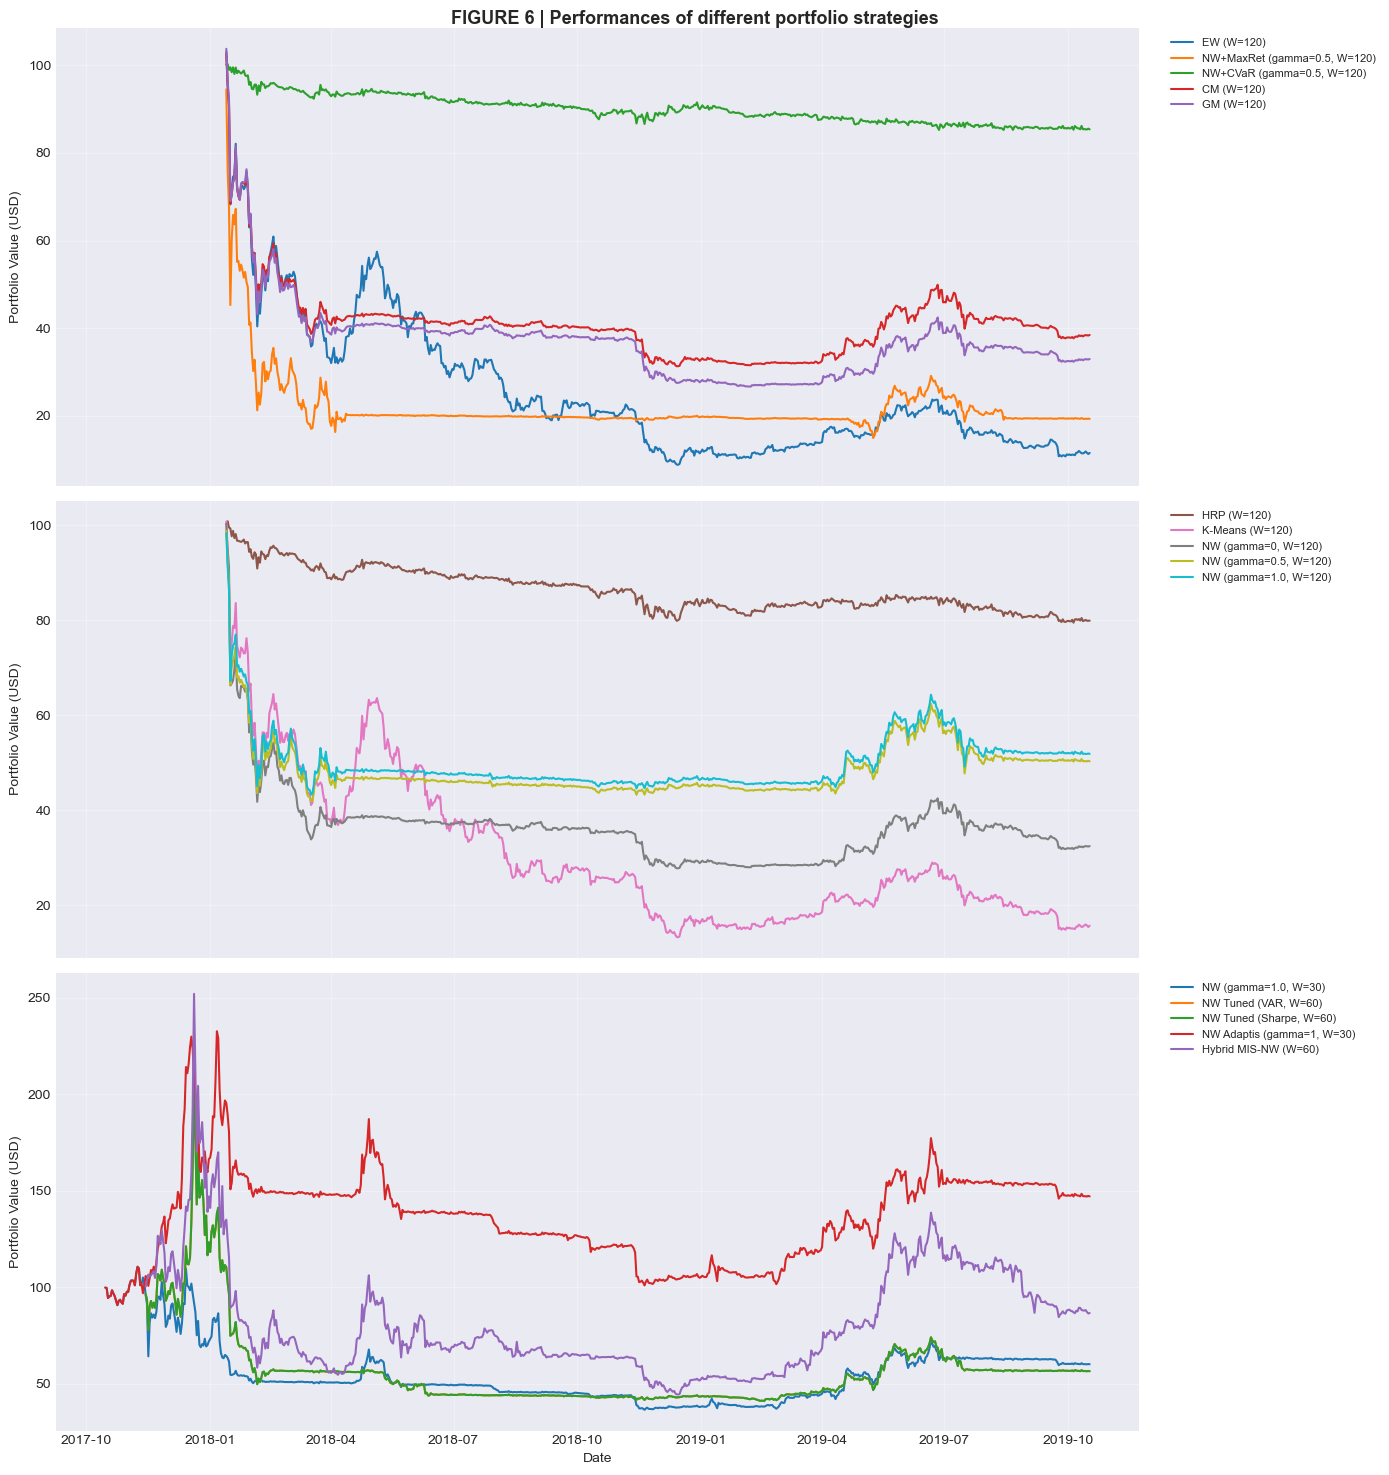

In [92]:
# Split all strategies into 3 groups of ~3 for readability
strategy_names = list(results.keys())
n = len(strategy_names)
group_size = (n + 2) // 3  # ceiling division

groups = [strategy_names[i:i+group_size] for i in range(0, n, group_size)]

# Color palette: use a consistent palette so the same strategy is easy to trace
colors = plt.cm.tab10.colors

fig, axes = plt.subplots(len(groups), 1, figsize=(14, 5 * len(groups)), sharex=True)
if len(groups) == 1:
    axes = [axes]

fig.suptitle('FIGURE 6 | Performances of different portfolio strategies', fontsize=13, fontweight='bold')

color_map = {name: colors[i % len(colors)] for i, name in enumerate(strategy_names)}

for ax, group in zip(axes, groups):
    for name in group:
        res = results[name]
        ax.plot(res['results_df']['date'],
                res['cumulative_returns'] * 100,
                label=name,
                color=color_map[name])
    ax.set_ylabel('Portfolio Value (USD)')
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()

In [93]:
period_ranges = [
    ('Jan-2018', '2017-10-01', '2018-01-31'),
    ('May-2018', '2018-02-01', '2018-05-31'),
    ('Sep-2018', '2018-06-01', '2018-09-30'),
    ('Jan-2019', '2018-10-01', '2019-01-31'),
    ('May-2019', '2019-02-01', '2019-05-31'),
    ('Sep-2019', '2019-06-01', '2019-09-30'),
]

table3_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 0:
            v = abs(calculate_var(segment, 0.95)) * 100
        else:
            v = np.nan
        row[period_label] = round(v, 4)
    table3_rows.append(row)

table3 = pd.DataFrame(table3_rows).set_index('Strategy')
print("TABLE 3 | VaR 95% (4-month window, scaled x100)")
display(table3)

TABLE 3 | VaR 95% (4-month window, scaled x100)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW (W=120),120.0,0.00,13.7904,9.5511,6.5477,9.4876,3.6840,8.2085
"NW+MaxRet (gamma=0.5, W=120)",120.0,0.50,20.8359,13.8567,0.6377,0.9561,2.7852,5.9835
"NW+CVaR (gamma=0.5, W=120)",120.0,0.50,1.5824,0.6456,0.6346,0.9314,0.4636,0.6149
CM (W=120),120.0,0.00,12.8261,5.8008,0.9993,1.7255,1.7011,3.8309
GM (W=120),120.0,0.00,13.4648,5.9287,1.1856,2.4277,1.8379,4.2622
HRP (W=120),120.0,0.00,1.7179,0.9663,0.5830,1.1357,0.6213,1.0185
K-Means (W=120),120.0,0.00,11.8277,8.0360,5.7625,8.1987,3.2929,6.4285
"NW (gamma=0, W=120)",120.0,0.00,12.4709,5.6166,1.1500,1.8397,1.5141,4.0012
"NW (gamma=0.5, W=120)",120.0,0.50,10.5557,5.6183,0.7120,0.9561,1.2827,3.0550


In [94]:
table4_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        row[period_label] = round(sr, 4)
    table4_rows.append(row)

table4 = pd.DataFrame(table4_rows).set_index('Strategy')
print("TABLE 4 | Sharpe Ratio (4-month window)")
display(table4)

TABLE 4 | Sharpe Ratio (4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW (W=120),120.0,0.00,-0.2532,-0.0425,-0.0986,-0.1270,0.2016,-0.1298
"NW+MaxRet (gamma=0.5, W=120)",120.0,0.50,-0.2786,-0.0371,-0.0381,-0.0152,0.0875,-0.0577
"NW+CVaR (gamma=0.5, W=120)",120.0,0.50,-0.2091,-0.0405,-0.0672,-0.0203,-0.0454,-0.0334
CM (W=120),120.0,0.00,-0.2508,-0.0984,-0.0577,-0.1500,0.1904,-0.0598
GM (W=120),120.0,0.00,-0.2355,-0.1032,-0.0537,-0.1873,0.1775,-0.0526
HRP (W=120),120.0,0.00,-0.2938,-0.0564,-0.0728,-0.0740,0.0778,-0.0869
K-Means (W=120),120.0,0.00,-0.2741,-0.0410,-0.1153,-0.1281,0.1925,-0.1430
"NW (gamma=0, W=120)",120.0,0.00,-0.3442,-0.1053,-0.0523,-0.1514,0.1851,-0.0694
"NW (gamma=0.5, W=120)",120.0,0.50,-0.4018,-0.0450,-0.0546,-0.0152,0.1567,-0.0498


In [95]:
table5_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    row    = {'Strategy': strat_name}
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_g = getattr(strat, 'gamma', '-')
    row['W'] = f"{avg_w:.1f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    row['G'] = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    for period_label, start, end in period_ranges:
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        row[period_label] = round(rr, 4)
    table5_rows.append(row)

table5 = pd.DataFrame(table5_rows).set_index('Strategy')
print("TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)")
display(table5)

TABLE 5 | Rachev Ratio (alpha=10%, 4-month window)


,W,G,Jan-2018,May-2018,Sep-2018,Jan-2019,May-2019,Sep-2019
Strategy,,,,,,,,
EW (W=120),120.0,0.00,0.3926,0.8889,0.8062,0.7200,1.7430,0.5381
"NW+MaxRet (gamma=0.5, W=120)",120.0,0.50,0.8077,1.0818,0.8598,1.0171,1.7224,0.8073
"NW+CVaR (gamma=0.5, W=120)",120.0,0.50,0.6995,1.1358,0.8291,0.9979,1.0502,1.1015
CM (W=120),120.0,0.00,0.3969,0.7612,0.7865,0.6506,2.0115,0.7510
GM (W=120),120.0,0.00,0.4126,0.7515,0.7760,0.5600,1.6893,0.7353
HRP (W=120),120.0,0.00,0.5318,1.0583,0.8252,0.9448,1.4234,0.8857
K-Means (W=120),120.0,0.00,0.4741,0.9240,0.7244,0.7181,1.6500,0.5438
"NW (gamma=0, W=120)",120.0,0.00,0.2494,0.7591,0.7824,0.6389,2.1048,0.7820
"NW (gamma=0.5, W=120)",120.0,0.50,0.2422,1.0222,0.8540,1.0171,2.1687,0.8614


In [96]:
fase_pasar = {
    'Bearish':  ('2018-01-01', '2019-03-31'),
    'Recovery': ('2019-04-01', '2019-06-30'),
    'Stable':   ('2019-07-01', '2019-10-17')
}

sharpe_rows = []
rachev_rows = []
for strat in strategies:
    strat_name = strat.name
    if strat_name not in results: continue
    res = results[strat_name]
    df_res = res['results_df'].set_index('date')
    if hasattr(strat, 'param_history') and strat.param_history:
        avg_w = np.mean([p['window'] for p in strat.param_history])
        avg_g = np.mean([p['gamma'] for p in strat.param_history])
    elif hasattr(strat, 'window_size') and hasattr(strat, 'gamma'):
        avg_w, avg_g = strat.window_size, strat.gamma
    else:
        avg_w = getattr(strat, 'window_size', '-')
        avg_g = getattr(strat, 'gamma', '-')
    sr_row = {'Strategy': strat_name}
    w_label = f"{avg_w:.0f}" if isinstance(avg_w, (int, float)) and avg_w != '-' else avg_w
    g_label = f"{avg_g:.2f}" if isinstance(avg_g, (int, float)) and avg_g != '-' else avg_g
    sr_row['W'] = w_label
    sr_row['G'] = g_label
    rr_row = {'Strategy': strat_name, 'W': w_label, 'G': g_label}
    for fase, (start, end) in fase_pasar.items():
        segment = df_res.loc[start:end, 'return'].values
        if len(segment) > 1 and np.std(segment) > 1e-6:
            sr = np.mean(segment) / np.std(segment)
        else:
            sr = np.nan
        sr_row[fase] = round(sr, 4)
        if len(segment) > 5:
            rr = calculate_rachev_ratio(segment, alpha=0.10)
        else:
            rr = np.nan
        rr_row[fase] = round(rr, 4)
    sharpe_rows.append(sr_row)
    rachev_rows.append(rr_row)

table6_sharpe = pd.DataFrame(sharpe_rows).set_index('Strategy')
table6_rachev = pd.DataFrame(rachev_rows).set_index('Strategy')

print("TABLE 6 | Market Phase Performance")
print("\nPanel A: Sharpe Ratio")
display(table6_sharpe)
print("\nPanel B: Rachev Ratio (alpha=10%)")
display(table6_rachev)

TABLE 6 | Market Phase Performance

Panel A: Sharpe Ratio


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
EW (W=120),120,0.00,-0.0726,0.1286,-0.1301
"NW+MaxRet (gamma=0.5, W=120)",120,0.50,-0.0492,0.0832,-0.0769
"NW+CVaR (gamma=0.5, W=120)",120,0.50,-0.0537,-0.0516,-0.0071
CM (W=120),120,0.00,-0.0923,0.1844,-0.1022
GM (W=120),120,0.00,-0.0991,0.1732,-0.0950
HRP (W=120),120,0.00,-0.0657,0.0199,-0.0707
K-Means (W=120),120,0.00,-0.0804,0.1318,-0.1450
"NW (gamma=0, W=120)",120,0.00,-0.1072,0.1763,-0.1095
"NW (gamma=0.5, W=120)",120,0.50,-0.0704,0.1359,-0.0628



Panel B: Rachev Ratio (alpha=10%)


,W,G,Bearish,Recovery,Stable
Strategy,,,,,
EW (W=120),120,0.00,0.7933,1.2168,0.5712
"NW+MaxRet (gamma=0.5, W=120)",120,0.50,0.8023,1.3485,0.7987
"NW+CVaR (gamma=0.5, W=120)",120,0.50,0.9117,1.2737,1.0601
CM (W=120),120,0.00,0.6463,1.2463,0.7523
GM (W=120),120,0.00,0.6275,1.1627,0.7477
HRP (W=120),120,0.00,0.9034,1.2982,0.8528
K-Means (W=120),120,0.00,0.7952,1.1712,0.5645
"NW (gamma=0, W=120)",120,0.00,0.5982,1.2883,0.7615
"NW (gamma=0.5, W=120)",120,0.50,0.7107,1.4069,0.8656


In [97]:
# Bayesian parameter evolution plot removed (not applicable for static Grid Search tuning)


In [98]:
# Bayesian parameter summary removed (not applicable for static Grid Search tuning)
print("Grid Search Tuned Parameters:")
for metric, params in tuned_params.items():
    print(f"  {metric}: W={params['W']}, G={params['G']:.1f}")


Grid Search Tuned Parameters:
  VAR: W=60, G=0.4
  SHARPE: W=60, G=0.4
  RACHEV: W=60, G=0.4
  MDD: W=60, G=0.4
  RETURN: W=60, G=0.4
  HYBRID: W=60, G=0.4


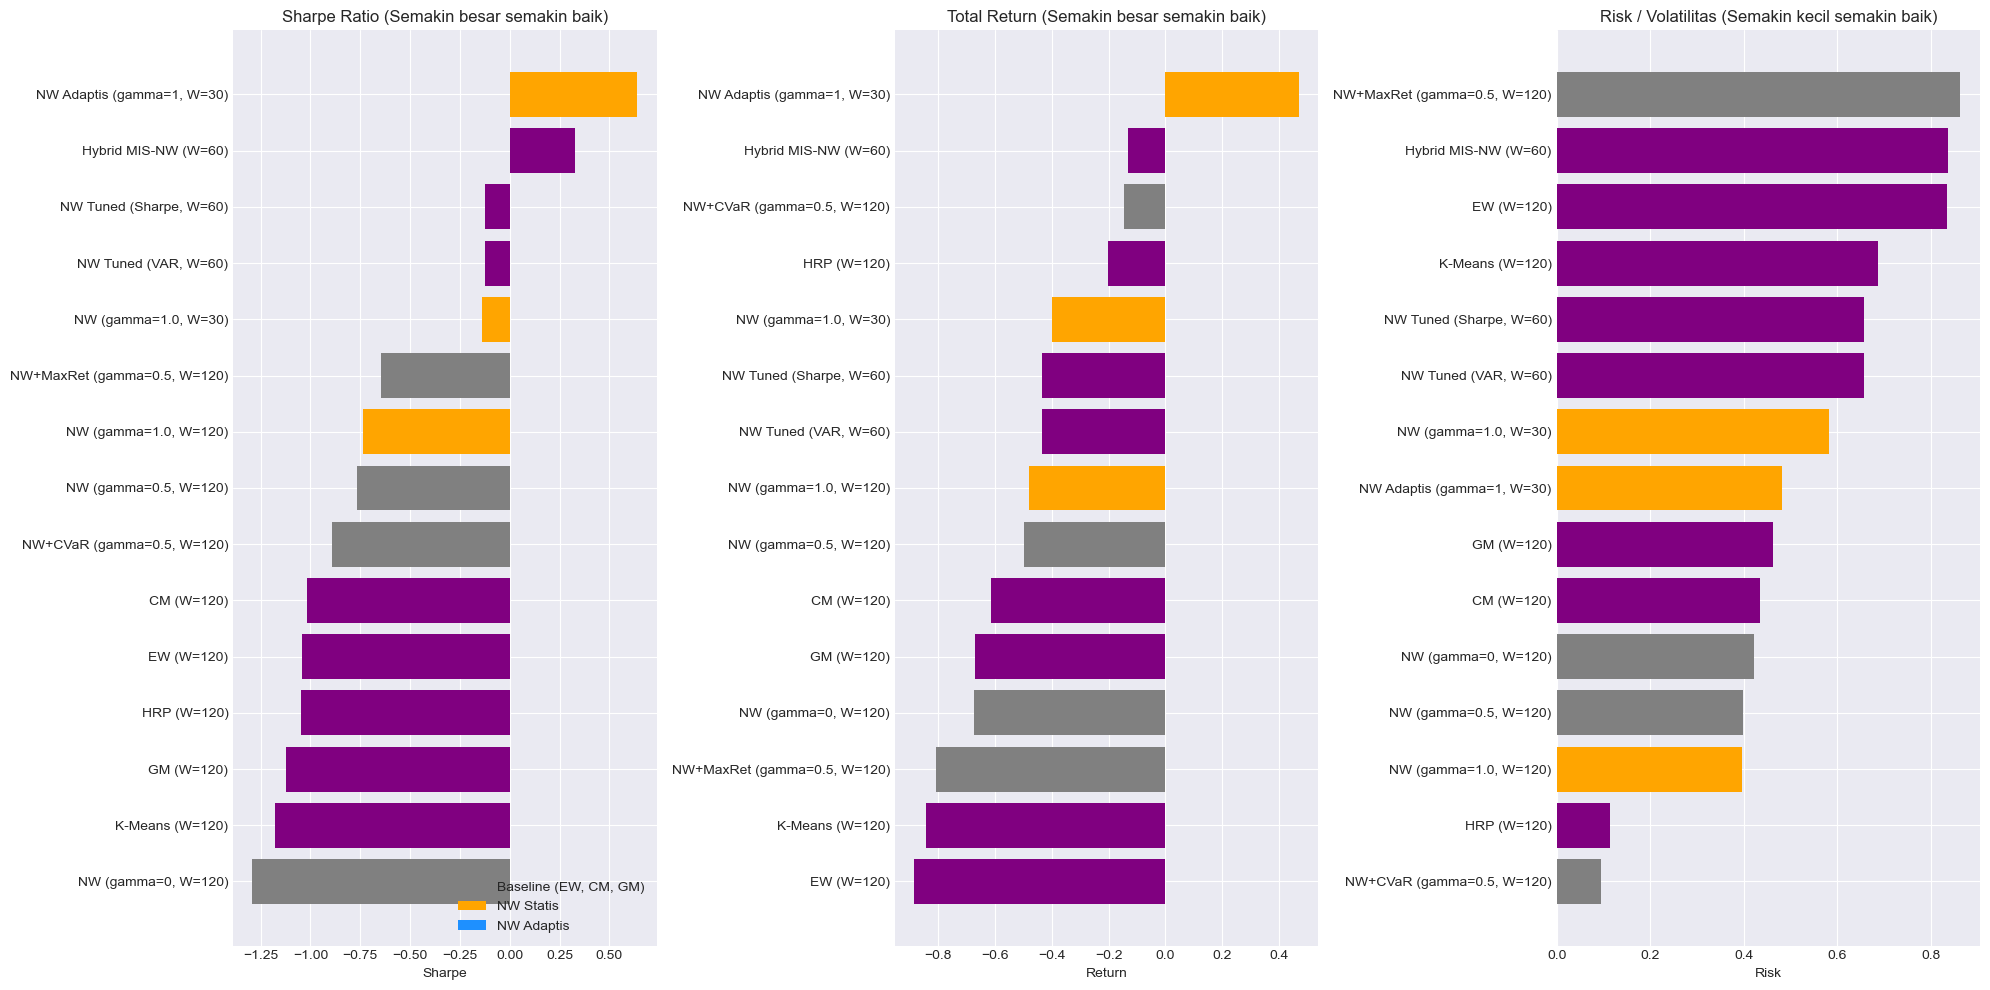

In [99]:
import numpy as np

data_rows = []
for strat_name, res in results.items():
    df_res = res['results_df']
    returns = df_res['return'].dropna().values
    
    if len(returns) > 0:
        tot_ret = np.prod(1 + returns) - 1 # or np.sum(returns) if log returns
        risk = np.std(returns) * np.sqrt(365) # annualized volatility
        sharpe = (np.mean(returns) / np.std(returns)) * np.sqrt(365) if np.std(returns) > 1e-6 else 0
    else:
        tot_ret, risk, sharpe = 0, 0, 0
        
    data_rows.append({'Strategy': strat_name, 'Return': tot_ret, 'Risk': risk, 'Sharpe': sharpe})

comparison = pd.DataFrame(data_rows).set_index('Strategy')

def get_color(strategy_name):
    if strategy_name in ['EW', 'CM', 'CM 30', 'GM'] or 'Static' not in strategy_name and 'gamma=0' in strategy_name:
        return 'gray'
    elif 'NW Static' in strategy_name or '(gamma' in strategy_name:
        return 'orange' # Static NW
    elif 'Adaptis' in strategy_name or 'GS' in strategy_name:
        return 'dodgerblue' # Adaptive NW
    else:
        return 'purple'

colors = [get_color(idx) for idx in comparison.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 10))

df_sharpe = comparison['Sharpe'].sort_values(ascending=True)
c_sharpe = [get_color(idx) for idx in df_sharpe.index]
axes[0].barh(df_sharpe.index, df_sharpe.values, color=c_sharpe)
axes[0].set_title('Sharpe Ratio (Semakin besar semakin baik)')
axes[0].set_xlabel('Sharpe')

df_return = comparison['Return'].sort_values(ascending=True)
c_return = [get_color(idx) for idx in df_return.index]
axes[1].barh(df_return.index, df_return.values, color=c_return)
axes[1].set_title('Total Return (Semakin besar semakin baik)')
axes[1].set_xlabel('Return')

df_risk = comparison['Risk'].sort_values(ascending=True)
c_risk = [get_color(idx) for idx in df_risk.index]
axes[2].barh(df_risk.index, df_risk.values, color=c_risk)
axes[2].set_title('Risk / Volatilitas (Semakin kecil semakin baik)')
axes[2].set_xlabel('Risk')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='gray', label='Baseline (EW, CM, GM)'),
                   Patch(facecolor='orange', label='NW Statis'),
                   Patch(facecolor='dodgerblue', label='NW Adaptis')]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

fig.savefig('horizontal_bar_comparison.png', dpi=300, bbox_inches='tight')


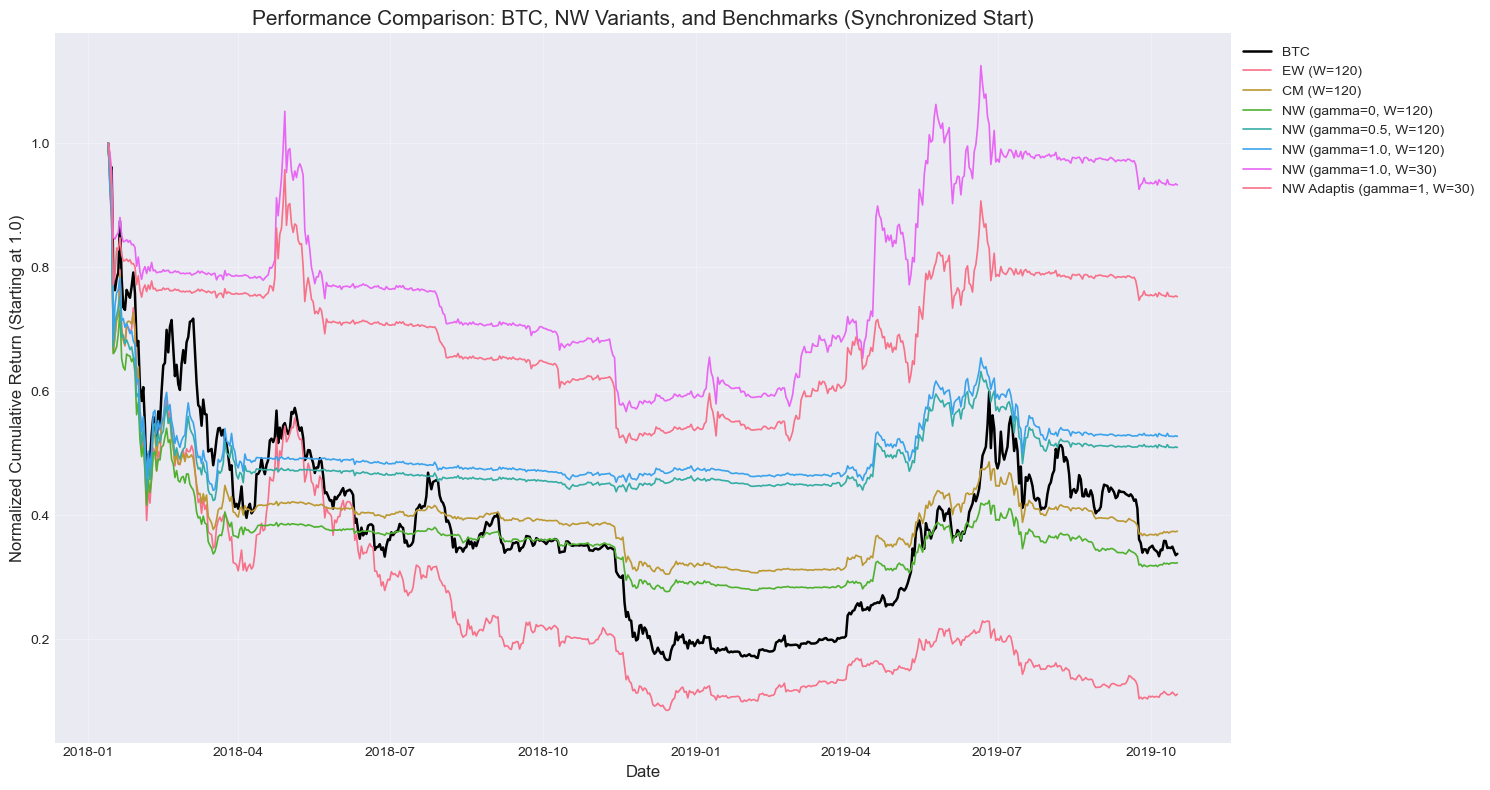

In [100]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

def plot_comparison_benchmarks(results, df_returns):
    if not results:
        print("No results found. Please run backtest first.")
        return
    
    # 1. Identify strategies to plot (same logic as before, excluding Hybrid)
    patterns = [
        ('EW', 'EW'),
        ('CM', 'CM'),
        ('NW gamma 0', 'NW (gamma=0, W='),
        ('NW gamma 0.5', 'NW (gamma=0.5, W='),
        ('NW gamma 1 (W=120)', 'NW (gamma=1.0, W=120)'),
        ('NW gamma 1 (W=30)', 'NW (gamma=1.0, W=30)'),
        ('NW Adaptive', 'NW Adaptis (gamma=1, W=30)')
    ]
    
    selected_strats = []
    for label, pattern in patterns:
        for actual_name in results.keys():
            if pattern in actual_name:
                selected_strats.append(actual_name)
                break
    
    if not selected_strats:
        print("No matching strategies found.")
        return

    # 2. Find common start date (the latest start date across all selected strategies)
    start_dates = [results[s]['results_df']['date'].min() for s in selected_strats]
    common_start_date = max(start_dates)
    
    plt.figure(figsize=(15, 8))
    
    # 3. Plot BTC (Normalized to common start date)
    ref_df = results[selected_strats[0]]['results_df']
    common_dates = ref_df[ref_df['date'] >= common_start_date]['date']
    
    # Re-calculate BTC to align with common_dates
    btc_bh_rets = df_returns.loc[common_dates, 'BTC'] if 'BTC' in df_returns.columns else df_returns.iloc[:,0].loc[common_dates]
    btc_bh_cum = (1 + btc_bh_rets).cumprod()
    btc_bh_cum = btc_bh_cum / btc_bh_cum.iloc[0] # Re-normalize so start=1.0
    
    plt.plot(common_dates, btc_bh_cum, label='BTC', color='black', linewidth=1.8)
    
    # 4. Plot Strategies (Normalized to common start date)
    for name in selected_strats:
        df = results[name]['results_df']
        mask = df['date'] >= common_start_date
        target_dates = df[mask]['date']
        cum_ret = df[mask]['cumulative_return']
        
        # Re-normalize so it starts at 1.0
        normalized_cum_ret = cum_ret / cum_ret.iloc[0]
        
        plt.plot(target_dates, normalized_cum_ret, label=name, linewidth=1.2)
    
    plt.title('Performance Comparison: BTC, NW Variants, and Benchmarks (Synchronized Start)', fontsize=15)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Normalized Cumulative Return (Starting at 1.0)', fontsize=12)
    plt.legend(fontsize=10, loc='upper left', bbox_to_anchor=(1, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_comparison_benchmarks(results, df_returns)


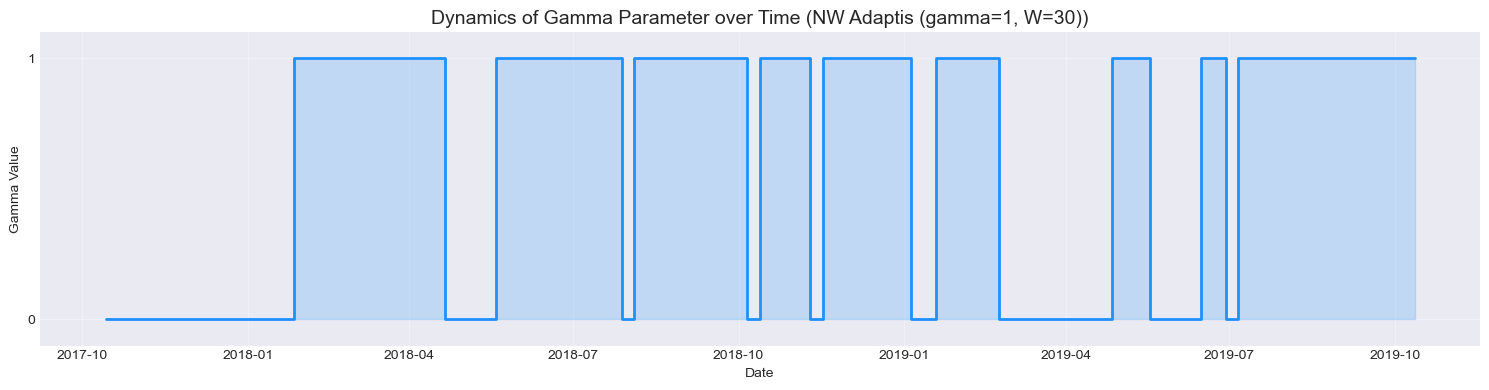

In [101]:
def plot_gamma_dynamics(strategies):
    """
    Mencari strategi AdaptiveNetworkMarkowitz dalam daftar dan memplot histori gamma-nya.
    """
    adaptive_strat = None
    for s in strategies:
        if isinstance(s, AdaptiveNetworkMarkowitz):
            adaptive_strat = s
            break
    
    if adaptive_strat is None or not adaptive_strat.gamma_history:
        print("Strategi Adaptive NW tidak ditemukan atau histori kosong. Pastikan backtest sudah dijalankan.")
        return
    
    history_df = pd.DataFrame(adaptive_strat.gamma_history)
    history_df['date'] = pd.to_datetime(history_df['date'])
    
    plt.figure(figsize=(15, 4))
    plt.step(history_df['date'], history_df['gamma'], where='post', color='dodgerblue', linewidth=2)
    plt.fill_between(history_df['date'], history_df['gamma'], step="post", alpha=0.2, color='dodgerblue')
    
    plt.title(f'Dynamics of Gamma Parameter over Time ({adaptive_strat.name})', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Gamma Value')
    plt.ylim(-0.1, 1.1)
    plt.yticks([0, 1])
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_gamma_dynamics(strategies)